In [12]:
# k-means
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px




In [13]:
# used to download dataset from kaggle, kept to showcase what was done

# import kagglehub
#
# # Download latest version
# path = kagglehub.dataset_download("omkarbhujbalrao/pokemon-dataset-gen-1-9")
#
# print("Path to dataset files:", path)

In [14]:
# df = dataframe
df = pd.read_csv('./resources/pokemon-dataset-gen-1-9/versions/10/pokemondataset_updated.csv')

In [15]:
df.head()

,id,Name,Height(m),Weight{kg},HP,Attack,Defense,Sp.Atk,Sp.Def,Speed,...,Egg_Group_1,Egg_Group_2,Generation,Capture_Rate,Base_Happiness,Is_Baby,Egg_Cycles,Past_Type,Is_Pseudo_Legendary,Total_Stats
0,1,Bulbasaur,0.7,6.9,45,49,49,65,65,45,...,Monster,Plant,Gen-1,45,70,False,20,NaN,False,318
1,2,Ivysaur,1.0,13.0,60,62,63,80,80,60,...,Monster,Plant,Gen-1,45,70,False,20,NaN,False,405
2,3,Venusaur,2.0,100.0,80,82,83,100,100,80,...,Monster,Plant,Gen-1,45,70,False,20,NaN,False,525
3,4,Charmander,0.6,8.5,39,52,43,60,50,65,...,Monster,Dragon,Gen-1,45,70,False,20,NaN,False,309
4,5,Charmeleon,1.1,19.0,58,64,58,80,65,80,...,Monster,Dragon,Gen-1,45,70,False,20,NaN,False,405


In [16]:
# we pull the features we want to use for the clustering
stats = ['HP', 'Attack', 'Defense', 'Sp.Atk', 'Sp.Def','Speed']
# dropna is used to drop values if they're null
X = df[stats].dropna().values
# StandardScaler() normalizes the values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


k=2 done
k=3 done
k=4 done
k=5 done
k=6 done
k=7 done
k=8 done
k=9 done
k=10 done


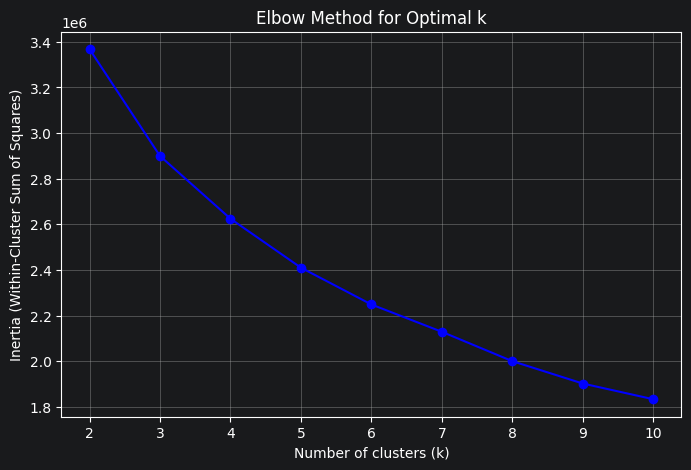

In [17]:
# find K-værdi ved at afprøve en række mulige:

inertias = []
K_range = range(2, 11)          # reduced from 15 → much faster

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=5,               # reduced from 10
        max_iter=300,
        algorithm='lloyd'       # or try 'elkan' sometimes faster
    )
    kmeans_temp.fit(X)
    inertias.append(kmeans_temp.inertia_)
    print(f"k={k} done")

# Plot
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [48]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X)

In [49]:
df_clustered= df.dropna(subset=stats).copy()
df_clustered['cluster'] = clusters

# PCA = principal component analysis 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

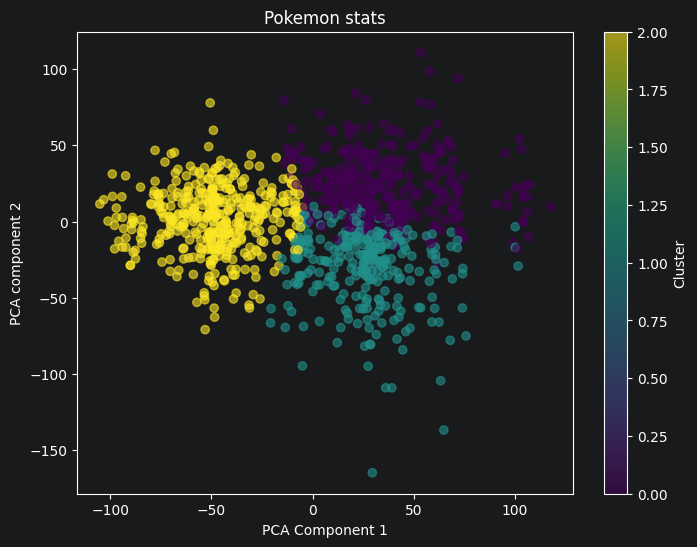

In [50]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA component 2')
plt.title('Pokemon stats')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [51]:
df_clustered['pca1'] = X_pca[:,0]
df_clustered['pca2'] = X_pca[:,1]



In [52]:
fig = px.scatter(
    df_clustered,
    x = 'pca1',
    y = 'pca2',
    color='cluster',
    hover_data=
    {
        'Name': True,
        'HP': True,
        'Attack': True,
        'Defense': True,
        'Sp.Atk': True,
        'Sp.Def': True,
        'Speed': True,
        'pca1': False,
        'pca2': False
    },
    title='K-means clustering of pokemon stats',
    width= 950,
    height=700,
    opacity=0.75
)
fig.update_traces(marker=dict(size=7))
fig.show()